In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import sys
sys.path.append('/home/jovyan/base_demo')
import base_tool

import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

In [10]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')
from sh518880 import *

In [11]:
instrument_id = '518880'
trade_ymd = '20260319'

param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
}

In [12]:
model_path = None
from strategy import StrategyDemo
strategy = StrategyDemo(model_path, param_dict)

-> Python解释器: /opt/conda/bin/python
-> Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
spawn模式启动
-> 当前 Python 解释器: /opt/conda/bin/python
-> 从delta/train.py获取到 79 个有数据的交易日
-> 过滤后剩余 79 个有数据的交易日
-> 过滤掉 651 个无数据日期: ['20250101', '20250102', '20250103', '20250104', '20250105', '20250106', '20250107', '20250108', '20250109', '20250110']...
-> 回测标的: 518880 (20250101 - 20261231)
-> 任务分配: 共 79 天，使用 4 个核心并行计算...


[SpawnPoolWorker-1] 日期 20250901 完成 | 盈亏: -8.20 | 成交: 98次 | 胜率: 7.1% | 平均持仓: 3.0快照
[SpawnPoolWorker-2] 日期 20251103 完成 | 盈亏: -6.50 | 成交: 77次 | 胜率: 3.9% | 平均持仓: 3.0快照
[SpawnPoolWorker-3] 日期 20260305 完成 | 盈亏: -4.50 | 成交: 42次 | 胜率: 9.5% | 平均持仓: 3.0快照
[SpawnPoolWorker-4] 日期 20251229 完成 | 盈亏: -7.00 | 成交: 69次 | 胜率: 2.9% | 平均持仓: 3.0快照
[SpawnPoolWorker-1] 日期 20250903 完成 | 盈亏: -7.50 | 成交: 70次 | 胜率: 0.0% | 平均持仓: 3.0快照
[SpawnPoolWorker-2] 日期 20251105 完成 | 盈亏: -5.70 | 成交: 67次 | 胜率: 1.5% | 平均持仓: 3.0快照
[SpawnPoolWorker-4] 日期 20251231 完成 | 盈亏: -12.80 | 成交: 120次 | 胜率: 6.7% | 平均持仓: 3.0快照
[SpawnPoolWorker-3] 日期 20260309 完成 | 盈亏: -5.90 | 成交: 44次 | 胜率: 4.5% | 平均持仓: 3.0快照
[SpawnPoolWorker-1] 日期 20250905 完成 | 盈亏: -5.00 | 成交: 52次 | 胜率: 0.0% | 平均持仓: 3.0快照
[SpawnPoolWorker-2] 日期 20251107 完成 | 盈亏: -3.10 | 成交: 30次 | 胜率: 0.0% | 平均持仓: 3.0快照
[SpawnPoolWorker-4] 日期 20260105 完成 | 盈亏: -8.00 | 成交: 80次 | 胜率: 1.2% | 平均持仓: 3.0快照
[SpawnPoolWorker-3] 日期 20260311 完成 | 盈亏: -4.10 | 成交: 44次 | 胜率: 2.3% | 平均持仓: 3.0快照
[SpawnPoolWork

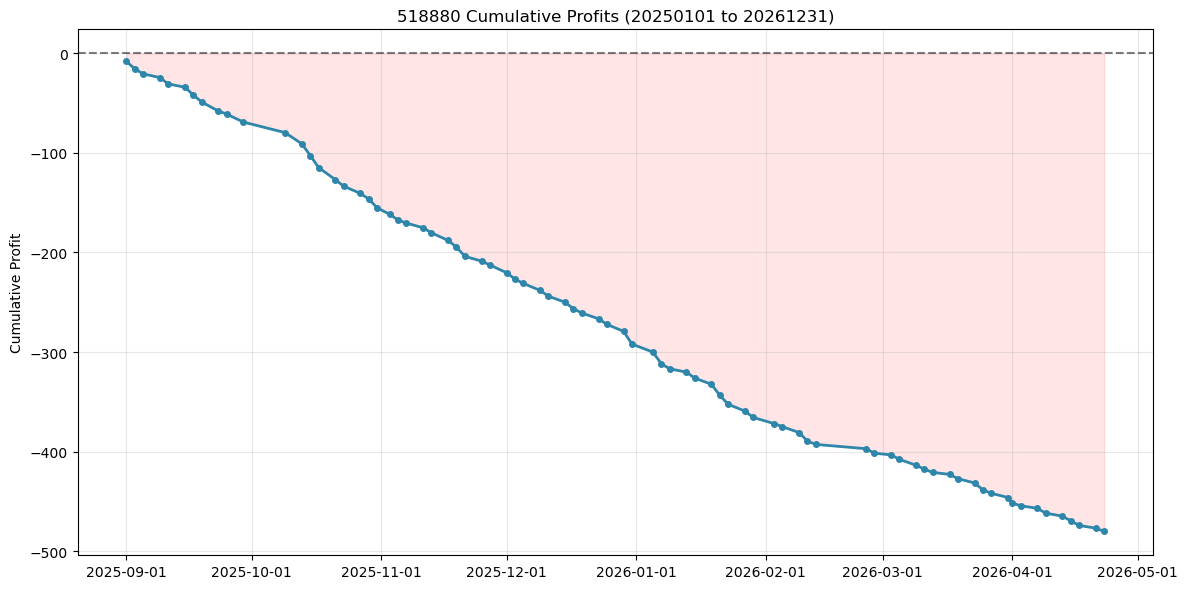


并行回测结果汇总:
{'测试天数': 79, '累计总盈亏': np.float64(-480.0), '总成交次数': 4875, '盈利交易次数': 148, '亏损交易次数': 4727, '加权每手胜率%': np.float64(3.04), '日均盈亏': np.float64(-6.08), '胜率(天)%': 0.0, '盈亏比(日均)': np.float64(0.0), '最大单日盈利': -1.7, '最大单日亏损': -12.8, '每笔交易平均盈利': np.float64(-0.1), '加权平均持仓时间(快照)': np.float64(3.0)}


In [13]:
# 导入修复的并行回测模块
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest
from multi_day_backtest import backtest_summary
# 运行并行回测
result_df = run_parallel_backtest(
    instrument_id=instrument_id,
    start_ymd="20250101",
    end_ymd="20261231",
    StrategyClass=StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    n_cores=4,
)


print("\n并行回测结果汇总:")
summary = backtest_summary(result_df)
print(summary)